In [2]:
pip install "numpy<2.0,>=1.24.0"

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


In [3]:
import tensorflow as tf
print(tf.__version__)

2.10.0


In [4]:
pip install opencv-python matplotlib

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'D:\\Project\\Waste Classification\\WasteClassification\\imageclassification\\Lib\\site-packages\\~5mpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-2bde3a66a51006b2b53eb373ff767a3f.dll'
Check the permissions.

You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


In [5]:
!pip list

Package                      Version
---------------------------- -----------
absl-py                      2.3.1
asttokens                    3.0.0
astunparse                   1.6.3
blinker                      1.9.0
cachetools                   5.5.2
certifi                      2025.8.3
charset-normalizer           3.4.3
click                        8.2.1
colorama                     0.4.6
comm                         0.2.3
contourpy                    1.3.2
cycler                       0.12.1
debugpy                      1.8.16
decorator                    5.2.1
exceptiongroup               1.3.0
executing                    2.2.0
Flask                        3.1.2
flatbuffers                  25.2.10
fonttools                    4.60.1
gast                         0.4.0
google-auth                  2.40.3
google-auth-oauthlib         0.4.6
google-pasta                 0.2.0
grpcio                       1.74.0
h5py                         3.14.0
idna                         3.10
ip

You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


In [6]:
import tensorflow as tf
import os

In [7]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [8]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [9]:
import tensorflow as tf

# Check available physical devices
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detected:", gpus)

# Quick test
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU Available (legacy check):", tf.test.is_gpu_available(cuda_only=False, min_cuda_compute_capability=None))


GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs Available: 1
Built with CUDA: True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU Available (legacy check): True


In [10]:
from tensorflow.python.client import device_lib

# List all local devices
devices = device_lib.list_local_devices()
for d in devices:
    if d.device_type == 'GPU':
        print(d.physical_device_desc)


device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [11]:
import cv2
import imghdr

In [12]:
data_dir = 'data1' 

In [13]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [14]:
for image_class in os.listdir(data_dir): 
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try: 
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts: 
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e: 
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

In [15]:
import numpy as np
from matplotlib import pyplot as plt

In [16]:
data = tf.keras.utils.image_dataset_from_directory('data1')

Found 15515 files belonging to 12 classes.


In [17]:
data

<BatchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [18]:
data_iterator = data.as_numpy_iterator()

In [19]:
batch = data_iterator.next()

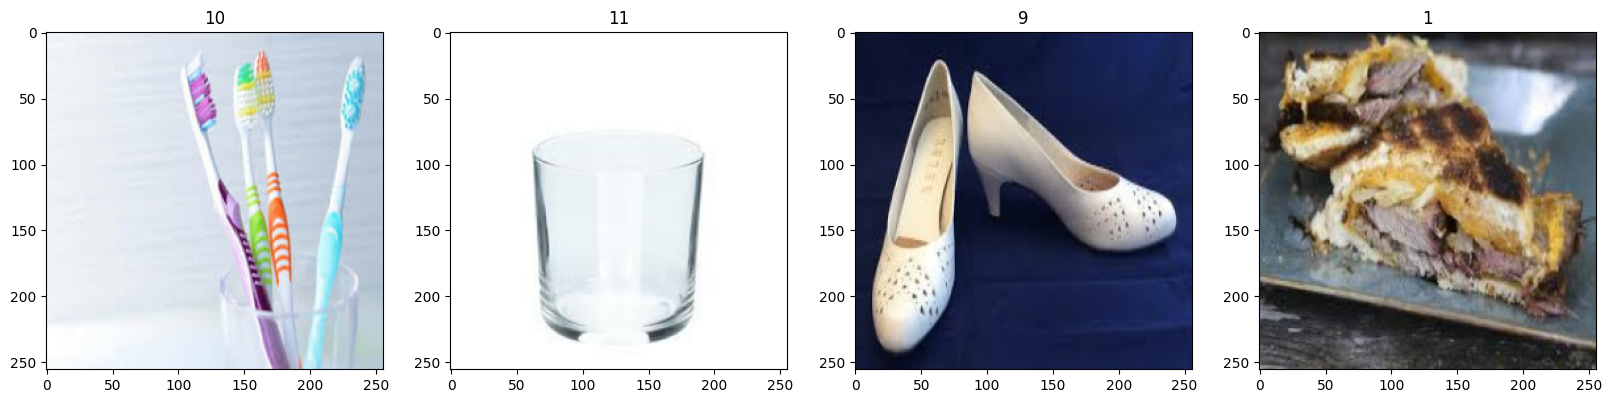

In [20]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [21]:
data = data.map(lambda x,y: (x/255, y))

In [22]:
scaled_iterator = data.as_numpy_iterator()

In [23]:
batch = scaled_iterator.next()

In [24]:
batch[0].min()

0.0

In [25]:
batch[0].max()

1.0

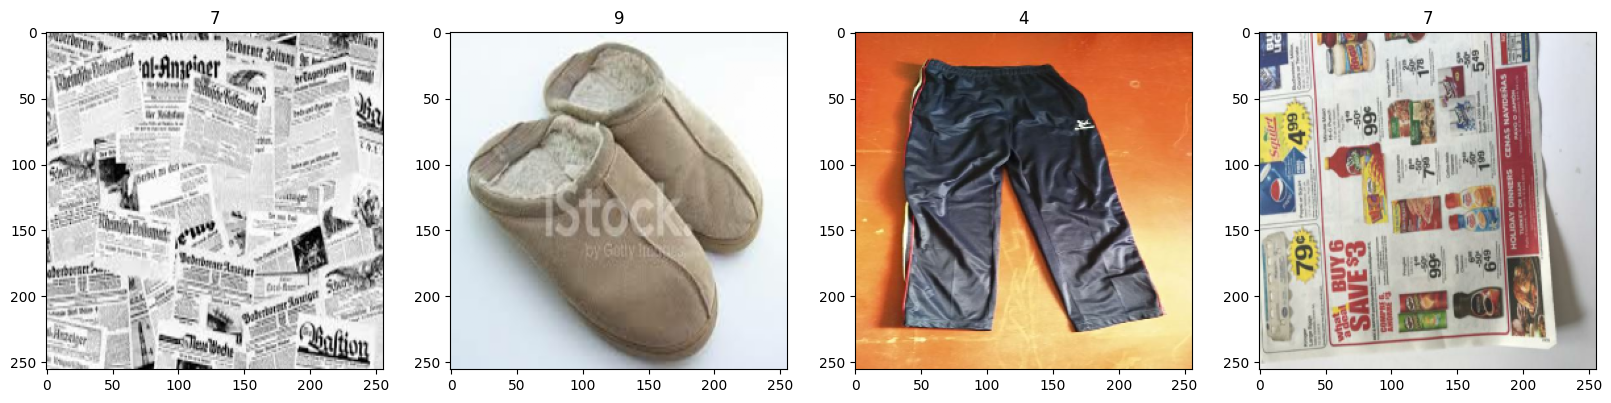

In [26]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

In [27]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [28]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

In [30]:
model = Sequential()

In [31]:
num_classes = 12

In [32]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Load VGG16 as base model (without top layers)
base_model = VGG16(include_top=False, input_shape=(256, 256, 3), weights="imagenet")
base_model.trainable = False  # freeze base model (use pretrained features)

# Build new model on top
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # multi-class
])

# Compile
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 8, 8, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 32768)             0         
                                                                 
 dense (Dense)               (None, 512)               16777728  
                                                                 
 batch_normalization (BatchN  (None, 512)              2048      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 12)                6156      
                                                      

In [33]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping and save best model
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    train,  # your training dataset
    validation_data=val,  # your validation dataset
    epochs=100,
    callbacks=callbacks
)


Epoch 1/100
339/339 [==============================] - 313s 839ms/step - loss: 0.7454 - accuracy: 0.7754 - val_loss: 0.4774 - val_accuracy: 0.8534
Epoch 2/100
339/339 [==============================] - 491s 1s/step - loss: 0.3070 - accuracy: 0.9064 - val_loss: 0.4673 - val_accuracy: 0.8602
Epoch 3/100
339/339 [==============================] - 372s 1s/step - loss: 0.1902 - accuracy: 0.9435 - val_loss: 0.4103 - val_accuracy: 0.8818
Epoch 4/100
339/339 [==============================] - 135s 395ms/step - loss: 0.1290 - accuracy: 0.9657 - val_loss: 0.3827 - val_accuracy: 0.8911
Epoch 5/100
339/339 [==============================] - 134s 394ms/step - loss: 0.0913 - accuracy: 0.9790 - val_loss: 0.3803 - val_accuracy: 0.8847
Epoch 6/100
339/339 [==============================] - 131s 385ms/step - loss: 0.0707 - accuracy: 0.9862 - val_loss: 0.4177 - val_accuracy: 0.8827
Epoch 7/100
339/339 [==============================] - 133s 390ms/step - loss: 0.0567 - accuracy: 0.9899 - val_loss: 0.4033 

In [41]:
# Unfreeze last 4 layers of VGG16
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Re-compile with smaller learning rate
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',  # multi-class
              metrics=['accuracy'])


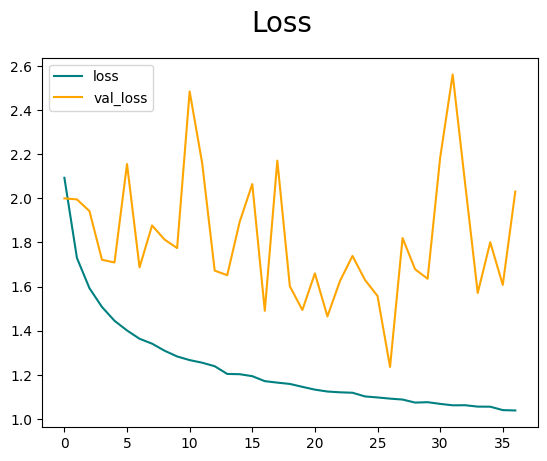

In [42]:
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

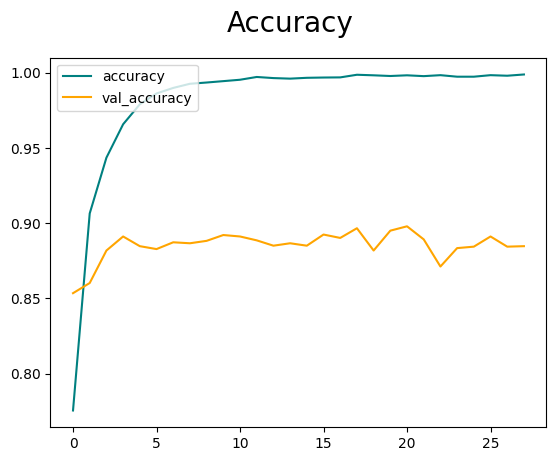

In [36]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [47]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

# ----------------------------
# 1. Data Loading & Augmentation
# ----------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Add validation split
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Use different subsets for training and validation
train_generator = train_datagen.flow_from_directory(
    'data1/',
    target_size=(256, 256),
    batch_size=32,
    class_mode='sparse',  # Explicitly set class mode
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    'data1/',
    target_size=(256, 256),
    batch_size=32,
    class_mode='sparse',  # Explicitly set class mode
    subset='validation'
)

num_classes = train_generator.num_classes

print(f"Number of classes: {num_classes}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

# ----------------------------
# 2. Build Base Model
# ----------------------------
base_model = ResNet50(include_top=False, input_shape=(256, 256, 3), weights="imagenet")
base_model.trainable = False  # Phase 1: freeze all

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary to verify architecture
model.summary()

callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint("resnet_best_model.h5", save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)
]

# ----------------------------
# 3. Train top layers first
# ----------------------------
print("Starting initial training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=callbacks,
    verbose=1
)

# ----------------------------
# 4. Fine-tune deeper layers
# ----------------------------
print("Starting fine-tuning...")
for layer in base_model.layers[-40:]:  # unfreeze last 40 layers
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Class balancing
class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(train_generator.classes), 
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

print("Class weights:", class_weights)

# Continue training
history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

Found 12415 images belonging to 12 classes.
Found 3100 images belonging to 12 classes.
Number of classes: 12
Training samples: 12415
Validation samples: 3100
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 8, 8, 2048)        23587712  
                                                                 
 global_average_pooling2d_4   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_10 (Dense)            (None, 512)               1049088   
                                                                 
 batch_normalization_5 (Batc  (None, 512)              2048      
 hNormalization)                                                 
                                                                 
 dropout_5 (Dropout)        

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



245/388 [=================>............] - ETA: 2:56 - loss: 1.4431 - accuracy: 0.5437

KeyboardInterrupt: 

In [38]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping and save best model
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ModelCheckpoint("best_model_resnet50.h5", save_best_only=True)
]

history = model.fit(
    train,  # your training dataset
    validation_data=val,  # your validation dataset
    epochs=100,
    callbacks=callbacks
)


Epoch 1/100
339/339 [==============================] - 169s 467ms/step - loss: 2.0929 - accuracy: 0.3682 - val_loss: 1.9995 - val_accuracy: 0.4430
Epoch 2/100
339/339 [==============================] - 99s 291ms/step - loss: 1.7297 - accuracy: 0.4592 - val_loss: 1.9949 - val_accuracy: 0.3908
Epoch 3/100
339/339 [==============================] - 99s 290ms/step - loss: 1.5925 - accuracy: 0.5019 - val_loss: 1.9421 - val_accuracy: 0.5048
Epoch 4/100
339/339 [==============================] - 98s 288ms/step - loss: 1.5074 - accuracy: 0.5276 - val_loss: 1.7214 - val_accuracy: 0.5016
Epoch 5/100
339/339 [==============================] - 99s 291ms/step - loss: 1.4448 - accuracy: 0.5423 - val_loss: 1.7090 - val_accuracy: 0.5126
Epoch 6/100
339/339 [==============================] - 98s 286ms/step - loss: 1.4009 - accuracy: 0.5572 - val_loss: 2.1552 - val_accuracy: 0.4665
Epoch 7/100
339/339 [==============================] - 99s 290ms/step - loss: 1.3632 - accuracy: 0.5672 - val_loss: 1.6869 

In [39]:
# Unfreeze last 4 layers of VGG16
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Re-compile with smaller learning rate
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',  # multi-class
              metrics=['accuracy'])


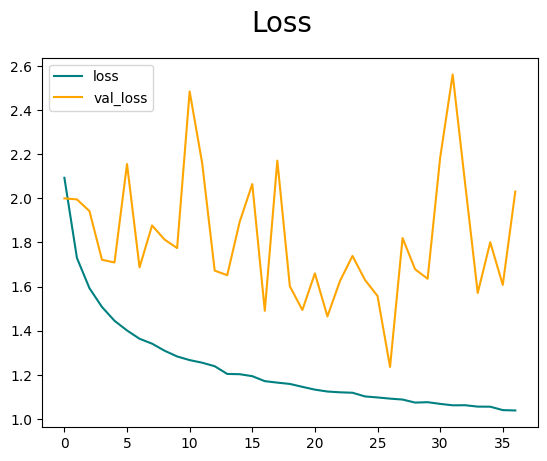

In [40]:
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()